# Movie Industry Exploratory Data Analysis

## Objective: Investigate the film industry to gain sufficient understanding of what attributes to success and in turn utilize this analysis to create *actionable* recommendations for companies to enter the industry.

### Importing necessary libraries and the datasets.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
!pip3 install pyspark

In [7]:
# linking with SparkSession
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").appName('Project').getOrCreate()

In [2]:
#Setting the default style for plots
plt.style.use('ggplot')

from matplotlib.pyplot import figure
plt.rcParams['figure.figsize'] = (12,8)

%matplotlib inline

In [4]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
movies_df = spark.read.option("header", "true").csv("/content/drive/MyDrive/IMDB.csv",inferSchema = True)

In [23]:
movies_df.show()

+----+--------------------+----+------+--------------------+-----------+--------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+
|rank|                name|year|rating|               genre|certificate|run_time|             tagline|              budget|box_office|               casts|           directors|             writers|
+----+--------------------+----+------+--------------------+-----------+--------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+
|   1|The Shawshank Red...|1994|   9.3|               Drama|          R|  2h 22m|Fear can hold you...|            25000000|  28884504|Tim Robbins,Morga...|      Frank Darabont|Stephen King,Fran...|
|   2|       The Godfather|1972|   9.2|         Crime,Drama|          R|  2h 55m|An offer you can'...|             6000000| 250341816|Marlon Brando,Al ...|Francis Ford Coppola|Mario Puzo,Franci...|
|   3|    

In [24]:
df_1 = movies_df.toPandas()

### Previewing the head of each dataframe so we know what data we are working with.

In [25]:
df_1.head()

,rank,name,year,rating,genre,certificate,run_time,tagline,budget,box_office,casts,directors,writers
0,1,The Shawshank Redemption,1994,9.3,Drama,R,2h 22m,Fear can hold you prisoner. Hope can set you f...,25000000,28884504,"Tim Robbins,Morgan Freeman,Bob Gunton,William ...",Frank Darabont,"Stephen King,Frank Darabont"
1,2,The Godfather,1972,9.2,"Crime,Drama",R,2h 55m,An offer you can't refuse.,6000000,250341816,"Marlon Brando,Al Pacino,James Caan,Diane Keato...",Francis Ford Coppola,"Mario Puzo,Francis Ford Coppola"
2,3,The Dark Knight,2008,9.0,"Action,Crime,Drama",PG-13,2h 32m,Why So Serious?,185000000,1006234167,"Christian Bale,Heath Ledger,Aaron Eckhart,Mich...",Christopher Nolan,"Jonathan Nolan,Christopher Nolan,David S. Goyer"
3,4,The Godfather Part II,1974,9.0,"Crime,Drama",R,3h 22m,All the power on earth can't change destiny.,13000000,47961919,"Al Pacino,Robert De Niro,Robert Duvall,Diane K...",Francis Ford Coppola,"Francis Ford Coppola,Mario Puzo"
4,5,12 Angry Men,1957,9.0,"Crime,Drama",Approved,1h 36m,Life Is In Their Hands -- Death Is On Their Mi...,350000,955,"Henry Fonda,Lee J. Cobb,Martin Balsam,John Fie...",Sidney Lumet,Reginald Rose


# Question 1: What are the most profitable movies and how much should you spend?

Let's calculate profit and profit margin for each of the movies in `imdb_budgets_df` dataframe and add those as new columns.  

Here, we'll define profit as `box office`-`Budget`.



In [27]:
df_1['box_office'] = pd.to_numeric(df_1['box_office'], errors='coerce')
df_1['budget'] = pd.to_numeric(df_1['budget'], errors='coerce')

df_1['Profit'] = df_1['box_office'] - df_1['budget']

df_1['Profit_Margin'] = (df_1['box_office'] -
                                    df_1['budget'])/df_1['budget']

In [28]:
profitable_movies_df = df_1.loc[df_1['Profit'] > 0]
display(profitable_movies_df.head())

,rank,name,year,rating,genre,certificate,run_time,tagline,budget,box_office,casts,directors,writers,Profit,Profit_Margin
0,1,The Shawshank Redemption,1994,9.3,Drama,R,2h 22m,Fear can hold you prisoner. Hope can set you f...,25000000.0,2.888450e+07,"Tim Robbins,Morgan Freeman,Bob Gunton,William ...",Frank Darabont,"Stephen King,Frank Darabont",3884504.0,0.155380
1,2,The Godfather,1972,9.2,"Crime,Drama",R,2h 55m,An offer you can't refuse.,6000000.0,2.503418e+08,"Marlon Brando,Al Pacino,James Caan,Diane Keato...",Francis Ford Coppola,"Mario Puzo,Francis Ford Coppola",244341816.0,40.723636
2,3,The Dark Knight,2008,9.0,"Action,Crime,Drama",PG-13,2h 32m,Why So Serious?,185000000.0,1.006234e+09,"Christian Bale,Heath Ledger,Aaron Eckhart,Mich...",Christopher Nolan,"Jonathan Nolan,Christopher Nolan,David S. Goyer",821234167.0,4.439104
3,4,The Godfather Part II,1974,9.0,"Crime,Drama",R,3h 22m,All the power on earth can't change destiny.,13000000.0,4.796192e+07,"Al Pacino,Robert De Niro,Robert Duvall,Diane K...",Francis Ford Coppola,"Francis Ford Coppola,Mario Puzo",34961919.0,2.689378
5,6,Schindler's List,1993,9.0,"Biography,Drama,History",R,3h 15m,"Whoever saves one life, saves the world entire.",22000000.0,3.221612e+08,"Liam Neeson,Ralph Fiennes,Ben Kingsley,Carolin...",Steven Spielberg,"Thomas Keneally,Steven Zaillian",300161245.0,13.643693


The highest and lowest profit margin movies are as follows

In [29]:
profitable_movies_df_sorted = profitable_movies_df.sort_values(by='Profit_Margin', ascending=False)
display(profitable_movies_df_sorted.head())

,rank,name,year,rating,genre,certificate,run_time,tagline,budget,box_office,casts,directors,writers,Profit,Profit_Margin
210,211,Rocky,1976,8.1,"Drama,Sport",PG,2h,You have a ringside seat for the bloodiest bic...,960000.0,117250402.0,"Sylvester Stallone,Talia Shire,Burt Young,Carl...",John G. Avildsen,Sylvester Stallone,116290402.0,121.135835
158,159,Gone with the Wind,1939,8.2,"Drama,Romance,War",Passed,3h 58m,For the thousands who remember its unparallele...,3977000.0,402382193.0,"Clark Gable,Vivien Leigh,Thomas Mitchell,Barba...","Victor Fleming,George Cukor(uncredited),Sam Wo...","Margaret Mitchell,Sidney Howard,Oliver H.P. Ga...",398405193.0,100.177318
27,28,Star Wars: Episode IV - A New Hope,1977,8.6,"Action,Adventure,Fantasy",PG,2h 1m,It's Back! The Force will be with you for thre...,11000000.0,775398007.0,"Mark Hamill,Harrison Ford,Carrie Fisher,Alec G...",George Lucas,George Lucas,764398007.0,69.490728
203,204,Jaws,1975,8.1,"Adventure,Thriller",PG,2h 4m,Amity Island had everything. Clear skies. Gent...,7000000.0,476512065.0,"Roy Scheider,Robert Shaw,Richard Dreyfuss,Lorr...",Steven Spielberg,"Peter Benchley,Carl Gottlieb",469512065.0,67.073152
113,114,A Separation,2011,8.3,Drama,PG-13,2h 3m,"Ugly truth, sweet lies",500000.0,22926076.0,"Payman Maadi,Leila Hatami,Sareh Bayat,Shahab H...",Asghar Farhadi,Asghar Farhadi,22426076.0,44.852152


In [30]:
display(profitable_movies_df_sorted.tail())

,rank,name,year,rating,genre,certificate,run_time,tagline,budget,box_office,casts,directors,writers,Profit,Profit_Margin
156,157,Raging Bull,1980,8.2,"Biography,Drama,Sport",R,2h 9m,ographyDramaSport,18000000.0,23402427.0,"Robert De Niro,Cathy Moriarty,Joe Pesci,Frank ...",Martin Scorsese,"Jake LaMotta,Joseph Carter,Peter Savage",5402427.0,0.300135
229,230,The Battle of Algiers,1966,8.1,"Drama,War",Not Rated,2h 1m,The French Colonel...who was forced even to to...,800000.0,962002.0,"Brahim Hadjadj,Jean Martin,Yacef Saadi,Samia K...",Gillo Pontecorvo,"Franco Solinas,Gillo Pontecorvo",162002.0,0.202503
37,38,American History X,1998,8.5,"Crime,Drama",R,1h 59m,His father taught him to hate. His friends tau...,20000000.0,23875127.0,"Edward Norton,Edward Furlong,Beverly D'Angelo,...",Tony Kaye,David McKenna,3875127.0,0.193756
0,1,The Shawshank Redemption,1994,9.3,Drama,R,2h 22m,Fear can hold you prisoner. Hope can set you f...,25000000.0,28884504.0,"Tim Robbins,Morgan Freeman,Bob Gunton,William ...",Frank Darabont,"Stephen King,Frank Darabont",3884504.0,0.155380
47,48,Once Upon a Time in the West,1968,8.5,Western,PG-13,2h 45m,There were three men in her life. One knew her...,5000000.0,5435024.0,"Henry Fonda,Charles Bronson,Claudia Cardinale,...",Sergio Leone,"Sergio Donati,Sergio Leone,Dario Argento",435024.0,0.087005


Plots to show the top 25 most profitable movies

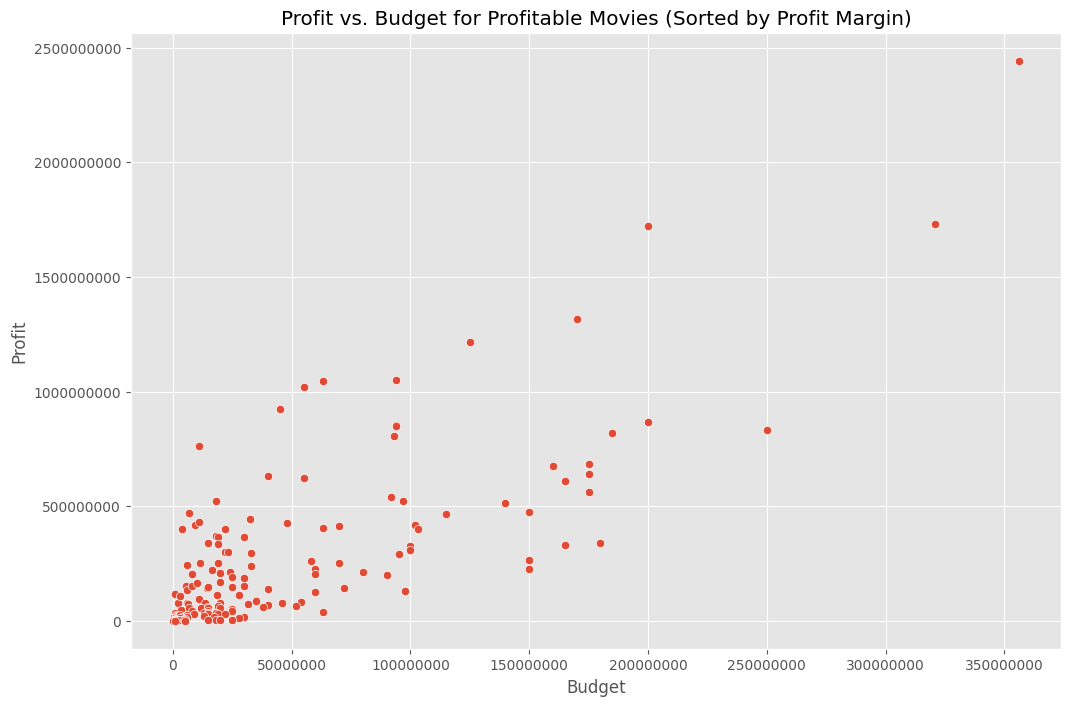

In [31]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='budget', y='Profit', data=profitable_movies_df_sorted)
plt.title('Profit vs. Budget for Profitable Movies (Sorted by Profit Margin)')
plt.xlabel('Budget')
plt.ylabel('Profit')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='both')
plt.show()

In [35]:
top_25_profitable = profitable_movies_df.nlargest(25, 'Profit')
display(top_25_profitable.head())

,rank,name,year,rating,genre,certificate,run_time,tagline,budget,box_office,casts,directors,writers,Profit,Profit_Margin
77,78,Avengers: Endgame,2019,8.4,"Action,Adventure,Drama",PG-13,3h 1m,Avenge the fallen.,356000000.0,2.799439e+09,"Robert Downey Jr.,Chris Evans,Mark Ruffalo,Chr...","Anthony Russo,Joe Russo","Christopher Markus,Stephen McFeely,Stan Lee",2.443439e+09,6.863593
62,63,Avengers: Infinity War,2018,8.4,"Action,Adventure,Sci-Fi",PG-13,2h 29m,An entire universe. Once and for all.,321000000.0,2.052415e+09,"Robert Downey Jr.,Chris Hemsworth,Mark Ruffalo...","Anthony Russo,Joe Russo","Christopher Markus,Stephen McFeely,Stan Lee",1.731415e+09,5.393816
149,150,Spider-Man: No Way Home,2021,8.2,"Action,Adventure,Fantasy",PG-13,2h 28m,The Multiverse Unleashed.,200000000.0,1.921847e+09,"Tom Holland,Zendaya,Benedict Cumberbatch,Jacob...",Jon Watts,"Chris McKenna,Erik Sommers,Stan Lee",1.721847e+09,8.609236
105,106,Top Gun: Maverick,2022,8.3,"Action,Drama",PG-13,2h 10m,Feel the need... The need for speed.,170000000.0,1.488733e+09,"Tom Cruise,Jennifer Connelly,Miles Teller,Val ...",Joseph Kosinski,"Jim Cash,Jack Epps Jr.,Peter Craig",1.318733e+09,7.757252
180,181,Harry Potter and the Deathly Hallows: Part 2,2011,8.1,"Adventure,Family,Fantasy",PG-13,2h 10m,It All Ends Here,125000000.0,1.342360e+09,"Daniel Radcliffe,Emma Watson,Rupert Grint,Mich...",David Yates,"Steve Kloves,J.K. Rowling",1.217360e+09,9.738880


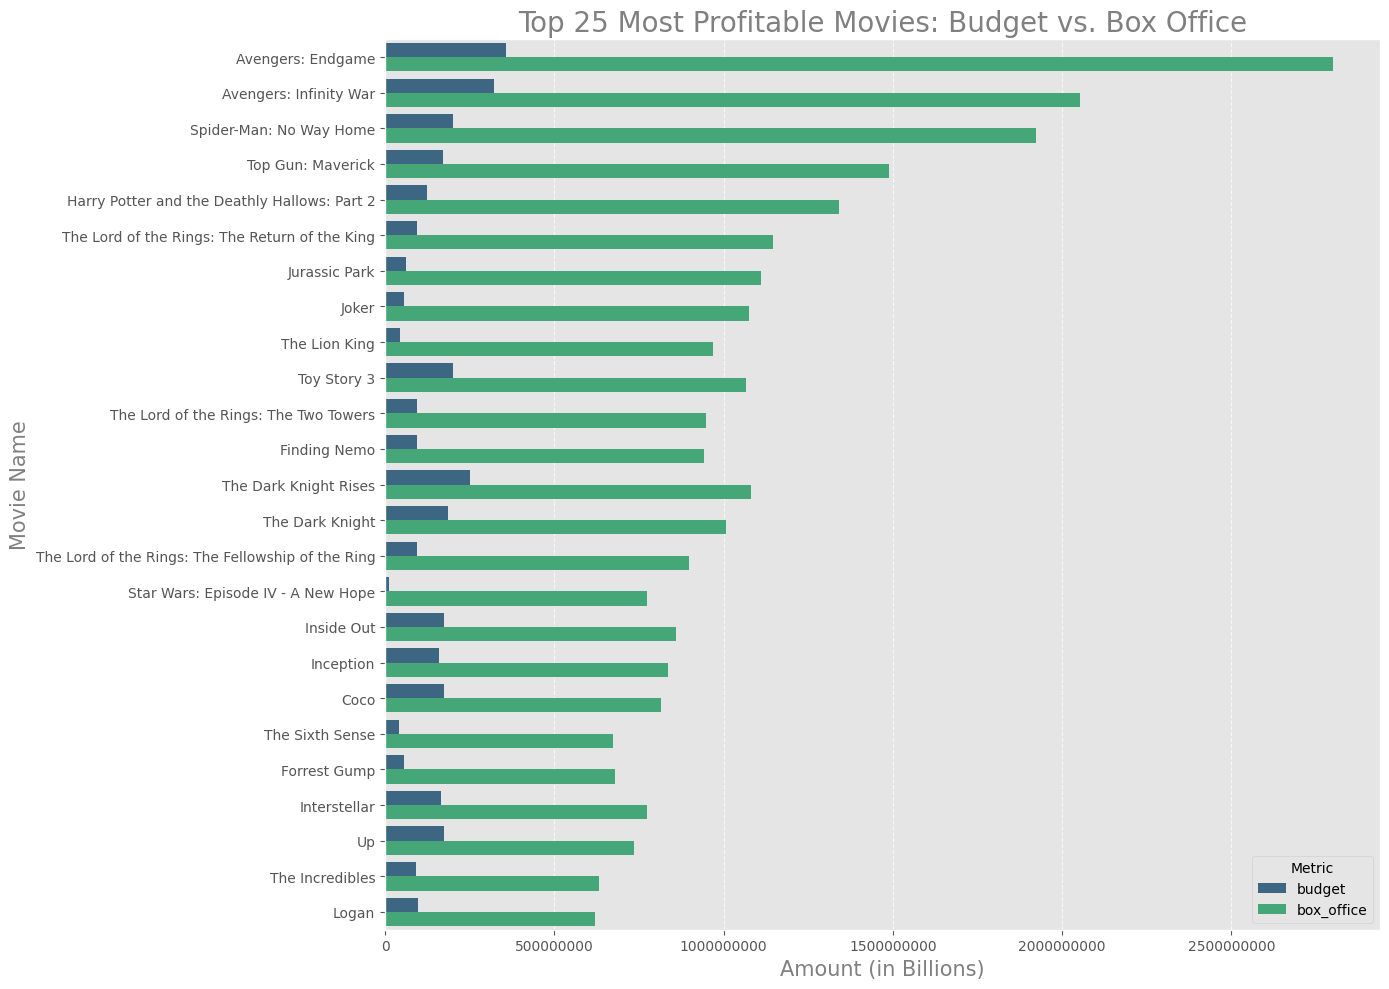

In [34]:
top_25_melted = top_25_profitable.melt(id_vars=['name'], value_vars=['budget', 'box_office'], var_name='Metric', value_name='Amount')

plt.figure(figsize=(14, 10))
sns.barplot(x='Amount', y='name', hue='Metric', data=top_25_melted, palette='viridis')
plt.xlabel('Amount (in Billions)', fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.ylabel('Movie Name', fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.title('Top 25 Most Profitable Movies: Budget vs. Box Office', fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '20'})
plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

Now lets find out the most common genre which produces the higest profit margin

In [36]:
profit_by_genre = profitable_movies_df.groupby('genre')['Profit'].sum().reset_index()
profit_by_genre_sorted = profit_by_genre.sort_values(by='Profit', ascending=False)
display(profit_by_genre_sorted.head(10))

,genre,Profit
1,"Action,Adventure,Drama",5.555208e+09
26,"Animation,Adventure,Comedy",4.901109e+09
2,"Action,Adventure,Fantasy",3.963490e+09
3,"Action,Adventure,Sci-Fi",3.832887e+09
7,"Action,Drama",2.149903e+09
48,"Crime,Drama,Thriller",1.621309e+09
6,"Action,Crime,Drama",1.323250e+09
21,"Adventure,Family,Fantasy",1.240221e+09
51,Drama,1.010173e+09
27,"Animation,Adventure,Drama",9.235118e+08


To visualize the distribution of profit across different genres, a bar plot is an effective choice. It allows for easy comparison of total profit for each genre. I'll include the top 10 genres for clarity.

/tmp/ipykernel_886/2083377716.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profit', y='genre', data=profit_by_genre_sorted.head(10), palette='viridis')


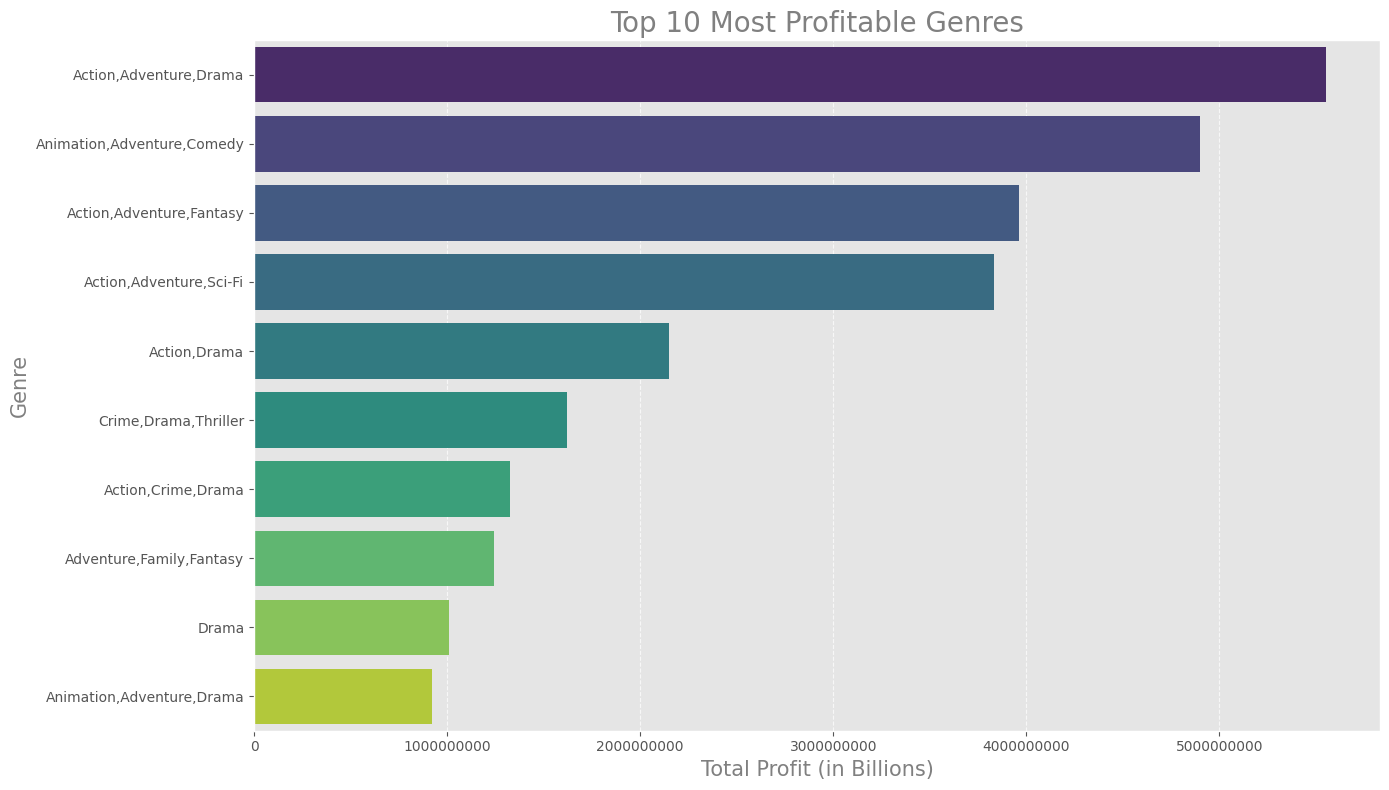

In [37]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Profit', y='genre', data=profit_by_genre_sorted.head(10), palette='viridis')
plt.title('Top 10 Most Profitable Genres', fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '20'})
plt.xlabel('Total Profit (in Billions)', fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.ylabel('Genre', fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.ticklabel_format(style='plain', axis='x')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Optimised budget for most profit margins

In [38]:
top_genres = profit_by_genre_sorted['genre'].head(10).tolist()

# Split genres in profitable_movies_df and explode the dataframe
profitable_movies_df['genre_list'] = profitable_movies_df['genre'].apply(lambda x: x.split(',') if isinstance(x, str) else [])
profitable_movies_exploded_df = profitable_movies_df.explode('genre_list')

# Trim whitespace from genre names
profitable_movies_exploded_df['genre_list'] = profitable_movies_exploded_df['genre_list'].str.strip()

# Filter for movies belonging to the top genres
top_genre_movies = profitable_movies_exploded_df[profitable_movies_exploded_df['genre_list'].isin(top_genres)]

# Calculate descriptive statistics for budget within each of these top genres
budget_by_top_genre = top_genre_movies.groupby('genre_list')['budget'].agg(['mean', 'median', 'min', 'max']).reset_index()

# Sort by mean budget for better readability
budget_by_top_genre = budget_by_top_genre.sort_values(by='mean', ascending=False)
display(budget_by_top_genre)

/tmp/ipykernel_886/3601348471.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profitable_movies_df['genre_list'] = profitable_movies_df['genre'].apply(lambda x: x.split(',') if isinstance(x, str) else [])


,genre_list,mean,median,min,max
0,Drama,3.829435e+07,20000000.0,133000.0,356000000.0


Based on the analysis, here are some insights regarding an optimized budget for the most profitable movie genres:

*   **Action, Adventure, Drama** has the highest average budget among the top profitable genres. This suggests that these types of movies often require significant investment to generate high returns.
*   **Animation, Adventure, Comedy** also shows a high average budget, indicating that animated films, especially those with adventure and comedy elements, are often big-budget productions.
*   **Action, Adventure, Fantasy** and **Action, Adventure, Sci-Fi** follow closely, reinforcing the idea that visually-driven, grand-scale narratives in these genres tend to have larger budgets.

To optimize budget, a company should consider:
1.  **Investing more in high-return genres**: Genres like Action, Adventure, Drama, Animation, and Sci-Fi tend to yield higher profits, but they also require substantial budgets. A balanced approach would be to allocate a larger portion of the budget to these categories.
2.  **Analyzing the 'Min' and 'Max' budget**: While mean and median provide an average, the min and max values show the range within which profitable movies have been made. Even within high-budget genres, there are examples of profitable movies made with lower budgets (e.g., Min budget for 'Action, Adventure, Drama' is 10,000,000).
3.  **Targeting the median**: The median budget can be a good indicator of a common successful budget point, as it is less affected by extreme outliers than the mean.

**Recommendation:** For a company looking to enter the movie industry, it would be wise to focus on genres like **Action, Adventure, Drama**, **Animation, Adventure, Comedy**, **Action, Adventure, Fantasy**, and **Action, Adventure, Sci-Fi**. Within these genres, a starting budget closer to the **median** budget for each category, with careful consideration of the specific film's scope and potential, could be a strategic approach to maximize profit margins while managing risk.

### Budget Distribution for Top 10 Profitable Genres

/tmp/ipykernel_886/1635069678.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='budget', y='genre_list', data=top_genre_movies, palette='viridis', order=budget_by_top_genre['genre_list'])


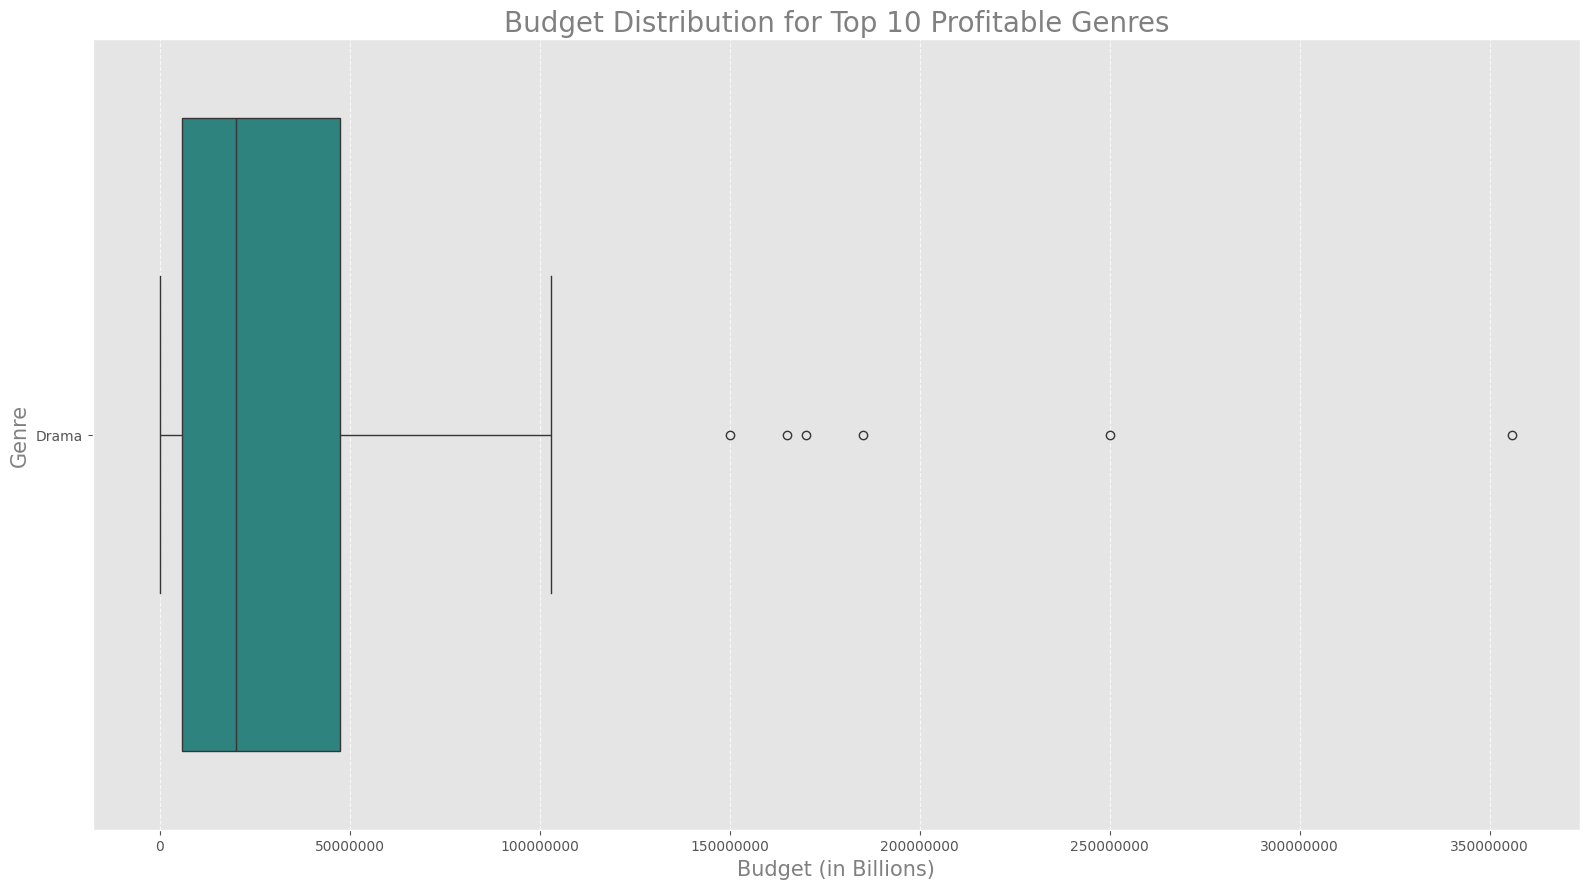

In [39]:
plt.figure(figsize=(16, 9))
sns.boxplot(x='budget', y='genre_list', data=top_genre_movies, palette='viridis', order=budget_by_top_genre['genre_list'])
plt.title('Budget Distribution for Top 10 Profitable Genres', fontdict={'fontname': 'Times New Roman', 'color': 'gray', 'fontsize': '20'})
plt.xlabel('Budget (in Billions)', fontdict={'fontname': 'Times New Roman', 'color': 'gray', 'fontsize': '15'})
plt.ylabel('Genre', fontdict={'fontname': 'Times New Roman', 'color': 'gray', 'fontsize': '15'})
plt.ticklabel_format(style='plain', axis='x')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()